In [1]:
!wget  https://download.microsoft.com/download/3/e/1/3e1c3f21-ecdb-4869-8368-6deba77b919f/kagglecatsanddogs_5340.zip

--2026-03-12 03:58:06--  https://download.microsoft.com/download/3/e/1/3e1c3f21-ecdb-4869-8368-6deba77b919f/kagglecatsanddogs_5340.zip
Resolving download.microsoft.com (download.microsoft.com)... 23.14.142.52, 2600:1407:3c00:1388::317f, 2600:1407:3c00:1389::317f
Connecting to download.microsoft.com (download.microsoft.com)|23.14.142.52|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 824887076 (787M) [application/octet-stream]
Saving to: ‘kagglecatsanddogs_5340.zip’

kagglecatsanddogs_5 100%[===================>] 786.67M   142MB/s    in 5.1s    

2026-03-12 03:58:11 (155 MB/s) - ‘kagglecatsanddogs_5340.zip’ saved [824887076/824887076]



In [2]:
!unzip kagglecatsanddogs_5340.zip

Streaming output truncated to the last 5000 lines.
  inflating: PetImages/Dog/5500.jpg  
  inflating: PetImages/Dog/5501.jpg  
  inflating: PetImages/Dog/5502.jpg  
  inflating: PetImages/Dog/5503.jpg  
  inflating: PetImages/Dog/5504.jpg  
  inflating: PetImages/Dog/5505.jpg  
  inflating: PetImages/Dog/5506.jpg  
  inflating: PetImages/Dog/5507.jpg  
  inflating: PetImages/Dog/5508.jpg  
  inflating: PetImages/Dog/5509.jpg  
  inflating: PetImages/Dog/551.jpg   
  inflating: PetImages/Dog/5510.jpg  
  inflating: PetImages/Dog/5511.jpg  
  inflating: PetImages/Dog/5512.jpg  
  inflating: PetImages/Dog/5513.jpg  
  inflating: PetImages/Dog/5514.jpg  
  inflating: PetImages/Dog/5515.jpg  
  inflating: PetImages/Dog/5516.jpg  
  inflating: PetImages/Dog/5517.jpg  
  inflating: PetImages/Dog/5518.jpg  
  inflating: PetImages/Dog/5519.jpg  
  inflating: PetImages/Dog/552.jpg   
  inflating: PetImages/Dog/5520.jpg  
  inflating: PetImages/Dog/5521.jpg  
  inflating: PetImages/Dog/5522.jpg  

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from keras.preprocessing.image import load_img
from keras.preprocessing import image
import os
import tqdm
import random
warnings.filterwarnings('ignore')

In [9]:
input_path = []
label = []

for clas in os.listdir('PetImages'):
  for path in tqdm.tqdm(os.listdir('PetImages/'+clas)):
    if clas == 'Cat':
      label.append(0)
    else:
      label.append(1)

    input_path.append(os.path.join('PetImages',clas, path))
print(input_path[0],label[0])


100%|██████████| 12501/12501 [00:00<00:00, 567856.11it/s]

PetImages/Dog/3321.jpg 1


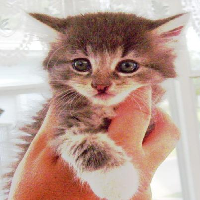

In [13]:
img = image.load_img('/content/PetImages/Cat/100.jpg',target_size=(200,200))
img

In [15]:
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip= True,
    vertical_flip = True,
    width_shift_range=0.2,
    height_shift_range=0.2
)

In [16]:
img = image.img_to_array(img)
type(img)

numpy.ndarray

In [17]:
img.shape

(200, 200, 3)

In [18]:
input_batch = img.reshape(1,200,200,3)

In [21]:
import os

output_dir = 'contenc/aug'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

i=0
for output in datagen.flow(input_batch, batch_size=1, save_to_dir=output_dir):
  i = i+1
  if i==10:
    break